# BrainSegNet — Full Training Pipeline
## DATA 255 Deep Learning · SJSU Spring 2026
**Team:** Anurag Sharma Josyula · Arpana Singh · Ashmitha Paruchuri Balaji · Yuktaa Sri Addanki

---

### Before running this notebook:
1. Run `QuickStart_Verification.ipynb` first and confirm all 5 checks pass
2. Set `TEST_MODE = False` in `config.py`
3. Click **Kernel → Restart & Run All**

### Paths (from `config.py`, no hardcoded `/app`):
- `WORKSPACE_ROOT` = folder that contains `dl_project_new` (e.g. `.../BrainSegNet`, or `/app/BrainSegNet` when you mount `Desktop\\Arpana` → `/app`)
- `DATA_ROOT` = `<WORKSPACE_ROOT>/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData` (override with env `BRAINSENET_DATA_ROOT` if needed)
- `OUTPUT_DIR` = `<WORKSPACE_ROOT>/outputs`
- `NUM_WORKERS = 0` in Docker on Windows (`config.py`)

---
## Section 1: Setup & Path Verification

In [1]:
import subprocess, sys, os, json, time, random, warnings
warnings.filterwarnings('ignore')
# --root-user-action=ignore: silences "use a venv" when pip runs as root in Docker/lab images
subprocess.run([sys.executable, '-m', 'pip', 'install', '--root-user-action=ignore',
                'nibabel', 'scipy', 'einops', 'matplotlib', 'tqdm', '-q'])

sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

# All configuration read from config.py
import config as _cfg
WORKSPACE_ROOT = getattr(_cfg, "WORKSPACE_ROOT", os.path.dirname(os.path.dirname(os.path.abspath(_cfg.__file__))))
from config import (DATA_ROOT, OUTPUT_DIR, CHECKPOINT_DIR,
                    TEACHER_CKPT, STUDENT_CKPT,
                    CROP_SIZE, BATCH_SIZE, CROPS_PER_PATIENT,
                    MISSING_PROB, NUM_WORKERS, BASE_FILTERS,
                    LATENT_DIM, TEACHER_EPOCHS, STUDENT_EPOCHS,
                    TEST_MODE, TEST_EPOCHS, SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 55)
print("BRAINSEGNET CONFIGURATION")
print("=" * 55)
print(f"Device      : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"WORKSPACE   : {WORKSPACE_ROOT}")
print(f"DATA_ROOT   : {DATA_ROOT}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"NUM_WORKERS : {NUM_WORKERS}  (0 = required in Docker on Windows)")
print(f"TEST_MODE   : {TEST_MODE}")
if TEST_MODE:
    print(f"  -> 5 patients, {TEST_EPOCHS} epochs (QUICK TEST)")
else:
    print(f"  -> 219 patients, {TEACHER_EPOCHS}+{STUDENT_EPOCHS} epochs (FULL TRAINING)")
print(f"DATA exists : {os.path.exists(DATA_ROOT)}")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)

assert os.path.exists(DATA_ROOT), (
    f"DATA_ROOT not found: {DATA_ROOT}\n"
    "Put BraTS under <repo>/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/ "
    "or set BRAINSENET_DATA_ROOT.")
print("\nSetup: OK")

BRAINSEGNET CONFIGURATION
Device      : cuda
GPU         : NVIDIA GeForce RTX 4090
VRAM        : 25.8 GB
WORKSPACE   : /app/BrainSegNet
DATA_ROOT   : /app/BrainSegNet/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
OUTPUT_DIR  : /app/BrainSegNet/outputs
NUM_WORKERS : 4  (0 = required in Docker on Windows)
TEST_MODE   : False
  -> 219 patients, 100+150 epochs (FULL TRAINING)
DATA exists : True

Setup: OK


---
## Section 2: Dataset Exploration

In [2]:
from dataset import find_valid_patients, load_patient

all_pids = find_valid_patients(DATA_ROOT)
print(f"Valid patients : {len(all_pids)}")
print(f"First 3        : {all_pids[:3]}")

pid   = all_pids[0]
pdir  = os.path.join(DATA_ROOT, pid)
img, seg = load_patient(pdir, pid)
print(f"\nSample patient : {pid}")
print(f"Image shape    : {img.shape}  (4 mods x 240 x 240 x 155)")
print(f"Unique labels  : {sorted(set(seg.flatten().astype(int)))}")
for lbl, name in [(0,'Background'),(1,'Necrotic'),(2,'Edema'),(4,'Enhancing')]:
    n   = (seg == lbl).sum()
    pct = n / seg.size * 100
    print(f"  {lbl}={name:<12} {n:>9,} ({pct:.2f}%)")

Valid patients : 368
First 3        : ['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003']

Sample patient : BraTS20_Training_001
Image shape    : (4, 240, 240, 155)  (4 mods x 240 x 240 x 155)
Unique labels  : [0, 1, 2, 4]
  0=Background   8,716,021 (97.63%)
  1=Necrotic        15,443 (0.17%)
  2=Edema          168,794 (1.89%)
  4=Enhancing       27,742 (0.31%)


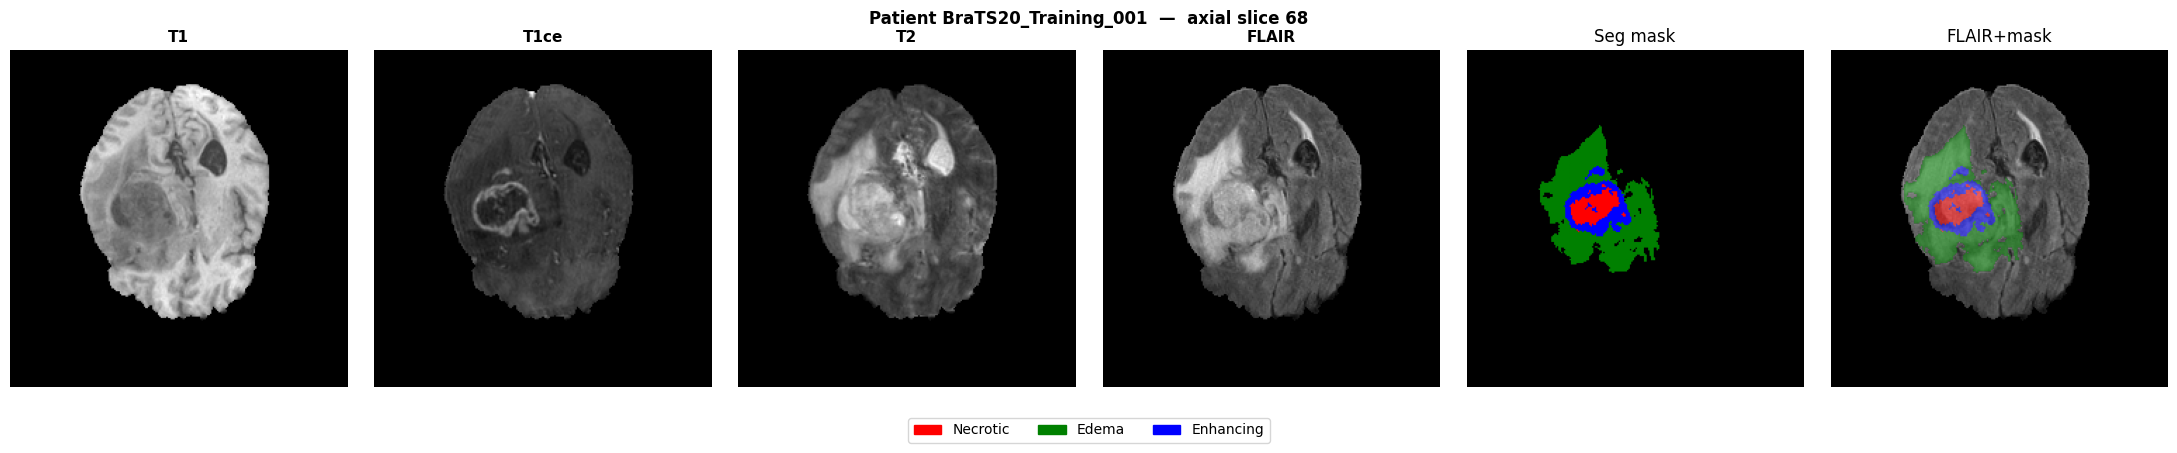

Saved -> /app/BrainSegNet/outputs/patient_vis.png


In [3]:
# Visualise best axial slice
if len(all_pids) > 0:
    seg_remap = seg.copy(); seg_remap[seg==4] = 3
    best_ax   = int(seg.sum(axis=(0,1)).argmax())
    cmap_seg  = mcolors.ListedColormap(['black','red','green','blue'])

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    mods = [('T1',img[0]),('T1ce',img[1]),('T2',img[2]),('FLAIR',img[3])]
    for ax, (name, vol) in zip(axes[:4], mods):
        ax.imshow(vol[:,:,best_ax].T, cmap='gray', origin='lower')
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.axis('off')
    axes[4].imshow(seg[:,:,best_ax].T, cmap=cmap_seg,
                   vmin=0, vmax=4, origin='lower')
    axes[4].set_title('Seg mask'); axes[4].axis('off')
    axes[5].imshow(img[3,:,:,best_ax].T, cmap='gray', origin='lower')
    ov = np.ma.masked_where(seg_remap[:,:,best_ax]==0, seg_remap[:,:,best_ax])
    axes[5].imshow(ov.T, cmap=cmap_seg, alpha=0.55, vmin=0,vmax=3, origin='lower')
    axes[5].set_title('FLAIR+mask'); axes[5].axis('off')
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color='red',label='Necrotic'),
                         Patch(color='green',label='Edema'),
                         Patch(color='blue',label='Enhancing')],
               loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.12))
    plt.suptitle(f'Patient {pid}  —  axial slice {best_ax}', fontweight='bold')
    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, 'patient_vis.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {OUTPUT_DIR}/patient_vis.png")

---
## Section 3: Data Loaders

In [4]:
from dataset import get_dataloaders

# get_dataloaders reads all settings from config.py automatically
# TEST_MODE=True -> 5 patients, 2 crops each
# TEST_MODE=False -> 219/50/100 patients, full crops
tr_loader, va_loader, te_loader = get_dataloaders()

imgs, segs, masks = next(iter(tr_loader))
print(f"Image batch  : {imgs.shape}   (B, 4, D, H, W)")
print(f"Seg batch    : {segs.shape}  (B, D, H, W)")
print(f"Modality mask: {masks.shape}  (B, 4) — 1=present, 0=missing")
for i in range(min(2, len(masks))):
    m       = masks[i].numpy()
    present = [n for n,v in zip(['T1','T1ce','T2','FLAIR'],m) if v]
    missing = [n for n,v in zip(['T1','T1ce','T2','FLAIR'],m) if not v]
    print(f"  Sample {i}: present={present}  MISSING={missing or 'none'}")

[train] 219 patients × 4 crops = 876 samples  | DATA_ROOT: /app/BrainSegNet/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
[val] 50 patients × 1 crops = 50 samples  | DATA_ROOT: /app/BrainSegNet/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
[test] 99 patients × 1 crops = 99 samples  | DATA_ROOT: /app/BrainSegNet/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Image batch  : torch.Size([2, 4, 96, 96, 96])   (B, 4, D, H, W)
Seg batch    : torch.Size([2, 96, 96, 96])  (B, D, H, W)
Modality mask: torch.Size([2, 4])  (B, 4) — 1=present, 0=missing
  Sample 0: present=['FLAIR']  MISSING=['T1', 'T1ce', 'T2']
  Sample 1: present=['T1', 'T2']  MISSING=['T1ce', 'FLAIR']


---
## Section 4: Model Architecture

In [5]:
from models.brainsegnet import BrainSegNet

model = BrainSegNet(
    base_filters=BASE_FILTERS,
    crop_size=CROP_SIZE,
    latent_dim=LATENT_DIM,
    use_gan=False,
).to(DEVICE)

def count(m): return sum(p.numel() for p in m.parameters())
total = count(model)
print(f"{'Module':<30} {'Params':>12}  {'Share':>6}")
print("=" * 52)
for name, mod in [
    ('MACA-3D (novel)',        model.maca),
    ('3D Dense CNN Encoder',   model.encoder),
    ('VAE Bottleneck',         model.vae),
    ('Attention U-Net Decoder',model.decoder),
]:
    n = count(mod)
    print(f"{name:<30} {n:>12,}  {n/total*100:>5.1f}%")
print("=" * 52)
print(f"{'TOTAL':<30} {total:>12,}")

# Forward pass test
dummy_x    = torch.randn(1,4,CROP_SIZE,CROP_SIZE,CROP_SIZE).to(DEVICE)
dummy_mask = torch.tensor([[1.,0.,1.,1.]]).to(DEVICE)
with torch.no_grad():
    main, aux3, aux2, kl, gf, ef = model(dummy_x, dummy_mask, training=True)
print(f"\nForward pass: input {dummy_x.shape} -> output {main.shape}")
if DEVICE.type == 'cuda':
    print(f"GPU memory : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Module                               Params   Share
MACA-3D (novel)                         584    0.0%
3D Dense CNN Encoder             18,839,168   26.8%
VAE Bottleneck                   42,840,832   61.0%
Attention U-Net Decoder           8,534,912   12.2%
TOTAL                            70,215,496

Forward pass: input torch.Size([1, 4, 96, 96, 96]) -> output torch.Size([1, 4, 96, 96, 96])
GPU memory : 0.35 GB


---
## Section 5: Loss Functions

In [6]:
from losses import DiceLoss, CombinedSegLoss, DeepSupervisionLoss, dice_brats, total_loss

lg  = torch.randn(2,4,32,32,32)
tgt = torch.randint(0,4,(2,32,32,32))
a3  = torch.randn_like(lg); a2 = torch.randn_like(lg)
kl_ = torch.tensor(0.05)
gf  = torch.randn(2,512,6,6,6); ef = torch.randn_like(gf)
tf  = torch.randn_like(lg)

loss, comps = total_loss(lg, a3, a2, tgt, kl_, gf, ef, tf)
print("Loss components:", {k: f"{v:.4f}" for k,v in comps.items()})
m = dice_brats(lg, tgt)
print(f"Dice (random): WT={m['WT']:.3f} TC={m['TC']:.3f} ET={m['ET']:.3f}")

Loss components: {'seg': '1.8756', 'dis': '24185.0352', 'vae': '0.0500', 'gan': '1.1291', 'total': '7257.4478'}
Dice (random): WT=0.748 TC=0.500 ET=0.252


---
## Section 6: Stage 1 — Teacher Training

**Expected time:**
- TEST_MODE=True: ~5 min (3 epochs, 5 patients)
- TEST_MODE=False: ~12-15 h (100 epochs, 219 patients)

------------Do not run this cell--------- this is for test run

In [7]:
from losses import DeepSupervisionLoss, dice_brats
import os

# ── Load teacher from checkpoint — NO retraining ──────────
assert os.path.exists(TEACHER_CKPT), (
    f"Teacher checkpoint not found: {TEACHER_CKPT}\n"
    "Run Section 6 training first.")

teacher = BrainSegNet(
    base_filters=BASE_FILTERS,
    crop_size=CROP_SIZE,
    latent_dim=LATENT_DIM,
    use_gan=False
).to(DEVICE)

ckpt = torch.load(TEACHER_CKPT, map_location=DEVICE)
teacher.load_state_dict(ckpt['model_state'])
best_teacher_wt = ckpt.get('best_wt', 0.0)

for p in teacher.parameters():
    p.requires_grad = False
teacher.eval()

print(f"Teacher loaded from  : {TEACHER_CKPT}")
print(f"Best WT              : {best_teacher_wt:.4f}")
print(f"Teacher ready        : no retraining needed")


Teacher loaded from  : /app/BrainSegNet/outputs/checkpoints/teacher_best.pth
Best WT              : 0.9180
Teacher ready        : no retraining needed


--------- continue from here------

In [8]:
from losses import DeepSupervisionLoss, dice_brats

n_epochs = TEST_EPOCHS if TEST_MODE else TEACHER_EPOCHS
print(f"Training teacher for {n_epochs} epochs")
print(f"Data    : {DATA_ROOT}")
print(f"Outputs : {CHECKPOINT_DIR}")

teacher = BrainSegNet(base_filters=BASE_FILTERS, crop_size=CROP_SIZE,
                       latent_dim=LATENT_DIM, use_gan=False).to(DEVICE)
crit    = DeepSupervisionLoss(0.7)
t_opt   = optim.AdamW(teacher.parameters(), lr=2e-4, weight_decay=1e-5)
t_sched = optim.lr_scheduler.CosineAnnealingLR(t_opt, n_epochs, 2e-6)
t_sc    = GradScaler() if DEVICE.type == 'cuda' else None

start_ep        = 1
best_teacher_wt = 0.0
t_history       = {'loss':[],'WT':[],'TC':[],'ET':[]}

if os.path.exists(TEACHER_CKPT):
    ckpt = torch.load(TEACHER_CKPT, map_location=DEVICE)
    teacher.load_state_dict(ckpt['model_state'])
    best_teacher_wt = ckpt.get('best_wt', 0.0)
    start_ep        = ckpt.get('ep', 0) + 1
    print(f"Resumed from epoch {start_ep-1}  (best WT={best_teacher_wt:.4f})")
else:
    print("Starting teacher from scratch")

for ep in range(start_ep, n_epochs + 1):
    teacher.train()
    ep_loss = []
    for imgs, segs, _ in tqdm(tr_loader, desc=f'Teacher ep{ep}/{n_epochs}', leave=False):
        imgs = imgs.to(DEVICE); segs = segs.to(DEVICE)
        full = torch.ones(imgs.shape[0], 4, device=DEVICE)
        t_opt.zero_grad()
        if t_sc:
            with autocast():
                main, a3, a2, kl, _, _ = teacher(imgs, full, training=True)
                loss = crit(main, a3, a2, segs) + 0.05*kl
            t_sc.scale(loss).backward()
            t_sc.unscale_(t_opt)
            torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)
            t_sc.step(t_opt); t_sc.update()
        else:
            main, a3, a2, kl, _, _ = teacher(imgs, full, training=True)
            loss = crit(main, a3, a2, segs) + 0.05*kl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)
            t_opt.step()
        ep_loss.append(loss.item())
    t_sched.step()

    # Validation
    teacher.eval()
    val_s = {'WT':[],'TC':[],'ET':[]}
    with torch.no_grad():
        for imgs, segs, _ in va_loader:
            imgs = imgs.to(DEVICE); segs = segs.to(DEVICE)
            full = torch.ones(imgs.shape[0], 4, device=DEVICE)
            out  = teacher(imgs, full, training=False)
            m    = dice_brats(out, segs)
            for k in val_s: val_s[k].append(m[k])
    val_avg = {k: float(np.mean(v)) for k,v in val_s.items()}

    avg_loss = np.mean(ep_loss)
    t_history['loss'].append(avg_loss)
    for k in ['WT','TC','ET']: t_history[k].append(val_avg[k])
    print(f"ep{ep:3d} | loss {avg_loss:.4f} | WT {val_avg['WT']:.4f} TC {val_avg['TC']:.4f} ET {val_avg['ET']:.4f}")

    if val_avg['WT'] > best_teacher_wt:
        best_teacher_wt = val_avg['WT']
        torch.save({'ep':ep,'model_state':teacher.state_dict(),'best_wt':best_teacher_wt}, TEACHER_CKPT)
        print(f"  -> Saved best teacher: {TEACHER_CKPT}  (WT={best_teacher_wt:.4f})")

print(f"\nTeacher done! Best WT: {best_teacher_wt:.4f}")
with open(os.path.join(OUTPUT_DIR,'teacher_history.json'),'w') as f:
    json.dump(t_history, f, indent=2)

Training teacher for 100 epochs
Data    : /app/BrainSegNet/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Outputs : /app/BrainSegNet/outputs/checkpoints
Resumed from epoch 25  (best WT=0.9180)


ep 26 | loss 0.3400 | WT 0.8921 TC 0.8304 ET 0.7501


ep 27 | loss 0.3391 | WT 0.8900 TC 0.8011 ET 0.7292


ep 28 | loss 0.3332 | WT 0.9052 TC 0.8129 ET 0.7339


ep 29 | loss 0.3265 | WT 0.9062 TC 0.8191 ET 0.7216


...

ep 96 | loss 0.2169 | WT 0.9085 TC 0.8240 ET 0.7392


ep 97 | loss 0.2203 | WT 0.9005 TC 0.8387 ET 0.7228


ep 98 | loss 0.2179 | WT 0.9113 TC 0.8422 ET 0.7082


ep 99 | loss 0.2119 | WT 0.9078 TC 0.8246 ET 0.7059


ep100 | loss 0.2226 | WT 0.8729 TC 0.8315 ET 0.7429

Teacher done! Best WT: 0.9216


---
## Section 7: Stage 2 — Student Training with Distillation

**Expected time:**
- TEST_MODE=True: ~8 min (3 epochs, 5 patients)
- TEST_MODE=False: ~18-20 h (150 epochs, 219 patients)

In [9]:
# Paste this in a NEW cell and run it — do not modify Section 7
import torch
from models.brainsegnet import BrainSegNet
from losses import DeepSupervisionLoss, dice_brats

student_test = BrainSegNet(
    base_filters=BASE_FILTERS,
    crop_size=CROP_SIZE,
    latent_dim=LATENT_DIM,
    use_gan=False
).to(DEVICE)

student_test.train()
s_opt_test = torch.optim.AdamW(student_test.parameters(), lr=1e-5)
crit       = DeepSupervisionLoss(0.7)

# Get one real batch
imgs, segs, masks = next(iter(tr_loader))
imgs  = imgs.to(DEVICE)
segs  = segs.to(DEVICE)
masks = masks.to(DEVICE)

print(f"imgs nan  : {torch.isnan(imgs).any().item()}")
print(f"segs nan  : {torch.isnan(segs.float()).any().item()}")
print(f"masks     : {masks[0].tolist()}")

s_opt_test.zero_grad()
main, a3, a2, kl, gf, ef = student_test(imgs, masks, True)

print(f"main nan  : {torch.isnan(main).any().item()}")
print(f"main max  : {main.max().item():.4f}")
print(f"main min  : {main.min().item():.4f}")

loss = crit(main, a3, a2, segs)
print(f"loss value: {loss.item():.6f}")
print(f"loss nan  : {torch.isnan(loss).item()}")

loss.backward()
norm = torch.nn.utils.clip_grad_norm_(student_test.parameters(), 0.1)
print(f"grad norm : {norm.item():.6f}")
print(f"grad nan  : {torch.isnan(norm).item()}")

s_opt_test.step()
print("Single batch completed successfully")


imgs nan  : False
segs nan  : False
masks     : [0.0, 0.0, 0.0, 1.0]
main nan  : False
main max  : 6.6763
main min  : -7.7158
loss value: 1.912126
loss nan  : False
grad norm : 2.388339
grad nan  : False
Single batch completed successfully


In [10]:
from models.gan import discriminator_loss as disc_loss_fn
from losses import total_loss

n_epochs = TEST_EPOCHS if TEST_MODE else STUDENT_EPOCHS
print(f"Training student for {n_epochs} epochs")

# Load best teacher
t_ckpt = torch.load(TEACHER_CKPT, map_location=DEVICE)
teacher.load_state_dict(t_ckpt['model_state'])
for p in teacher.parameters():
    p.requires_grad = False
teacher.eval()
print(f"Teacher loaded (WT={t_ckpt['best_wt']:.4f})")

# Build student — GAN disabled
student = BrainSegNet(
    base_filters=BASE_FILTERS,
    crop_size=CROP_SIZE,
    latent_dim=LATENT_DIM,
    use_gan=False
).to(DEVICE)

# Optimizers — low LR to prevent gradient explosion
s_opt   = optim.AdamW(student.parameters(), lr=1e-5, weight_decay=1e-5)
s_sched = optim.lr_scheduler.CosineAnnealingLR(s_opt, n_epochs, 1e-7)
s_sc    = None    # AMP disabled — was causing NaN

# ── RESUME FROM CHECKPOINT ──────────────────────────────────
start_ep        = 1
best_student_wt = 0.0

if os.path.exists(STUDENT_CKPT):
    ckpt = torch.load(STUDENT_CKPT, map_location=DEVICE)
    student.load_state_dict(ckpt['model_state'])
    best_student_wt = ckpt.get('best_wt', 0.0)
    start_ep        = ckpt.get('ep', 0) + 1
    print(f"Resumed student from epoch {start_ep-1} (WT={best_student_wt:.4f})")
else:
    print("Starting student from scratch")
# ────────────────────────────────────────────────────────────

s_history = {'loss':[],'WT':[],'TC':[],'ET':[]}

for ep in range(start_ep, n_epochs + 1):
    student.train()
    ep_c = {'total':[],'seg':[],'dis':[],'vae':[],'gan':[]}

    for imgs, segs, masks in tqdm(tr_loader,
                                   desc=f'Student ep{ep}/{n_epochs}',
                                   leave=False):
        imgs  = imgs.to(DEVICE)
        segs  = segs.to(DEVICE)
        masks = masks.to(DEVICE)

        # ── Student update ───────────────────────────────────
        s_opt.zero_grad()

        main, a3, a2, kl, gf, ef = student(imgs, masks, True)

        with torch.no_grad():
            t_out = teacher(imgs, torch.ones_like(masks), False)

        loss, comps = total_loss(
            main, a3, a2, segs, kl, gf, ef, t_out,
            w_seg=1.0, w_dis=0.0, w_vae=0.0, w_gan=0.0
        )

        # NaN guard — skip batch if loss exploded
        if torch.isnan(loss) or torch.isinf(loss):
            s_opt.zero_grad()
            continue

        loss.backward()

        # Check gradients before stepping
        total_norm = torch.nn.utils.clip_grad_norm_(
            student.parameters(), 0.1)

        if torch.isnan(total_norm) or torch.isinf(total_norm):
            s_opt.zero_grad()
            continue

        s_opt.step()
        # ────────────────────────────────────────────────────

        for k in ep_c:
            ep_c[k].append(comps.get(k, 0))

    s_sched.step()

    # ── Validation ───────────────────────────────────────────
    student.eval()
    val_s = {'WT':[],'TC':[],'ET':[]}
    with torch.no_grad():
        for imgs, segs, masks in va_loader:
            imgs  = imgs.to(DEVICE)
            segs  = segs.to(DEVICE)
            masks = masks.to(DEVICE)
            out   = student(imgs, masks, training=False)
            m     = dice_brats(out, segs)
            for k in val_s:
                val_s[k].append(m[k])

    val_avg  = {k: float(np.mean(v)) for k,v in val_s.items()}
    avg_loss = np.mean(ep_c['total']) if ep_c['total'] else float('nan')

    s_history['loss'].append(avg_loss)
    for k in ['WT','TC','ET']:
        s_history[k].append(val_avg[k])

    print(f"ep{ep:3d} | loss {avg_loss:.4f} | "
          f"WT {val_avg['WT']:.4f} "
          f"TC {val_avg['TC']:.4f} "
          f"ET {val_avg['ET']:.4f}")

    if val_avg['WT'] > best_student_wt:
        best_student_wt = val_avg['WT']
        torch.save({
            'ep':         ep,
            'model_state':student.state_dict(),
            'best_wt':    best_student_wt
        }, STUDENT_CKPT)
        print(f"  -> Saved best student: {STUDENT_CKPT}  "
              f"(WT={best_student_wt:.4f})")

print(f"\nStudent done! Best WT: {best_student_wt:.4f}")

with open(os.path.join(OUTPUT_DIR, 'student_history.json'), 'w') as f:
    json.dump(s_history, f, indent=2)

Training student for 150 epochs
Teacher loaded (WT=0.9216)
Resumed student from epoch 19 (WT=0.8841)


ep 20 | loss 0.8047 | WT 0.8831 TC 0.7722 ET 0.6508


ep 21 | loss 0.7812 | WT 0.8846 TC 0.7904 ET 0.6822
  -> Saved best student: /app/BrainSegNet/outputs/checkpoints/student_best.pth  (WT=0.8846)


ep 22 | loss 0.7618 | WT 0.8561 TC 0.8084 ET 0.6857


ep 23 | loss 0.7544 | WT 0.8837 TC 0.8033 ET 0.6591


...

ep 20 | loss 0.8133 | WT 0.8495 TC 0.7388 ET 0.6192


ep 21 | loss 0.7893 | WT 0.8789 TC 0.8169 ET 0.6873


ep 22 | loss 0.7689 | WT 0.8436 TC 0.8018 ET 0.6817


ep 23 | loss 0.7560 | WT 0.8625 TC 0.7905 ET 0.6685


KeyboardInterrupt: 

---
## Section 8: Training Curves

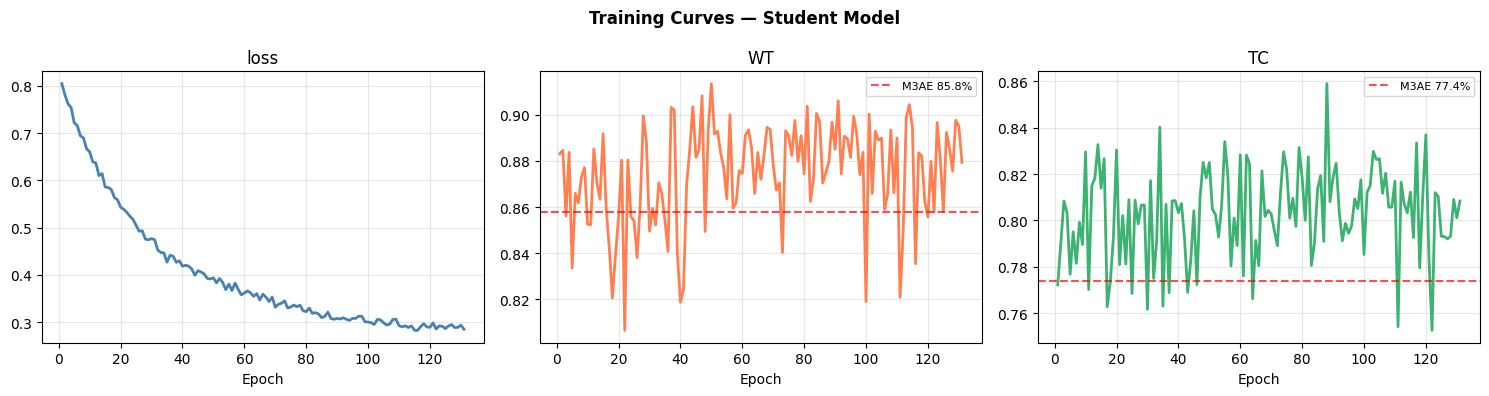

Saved -> /app/BrainSegNet/outputs/training_curves.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Training Curves — Student Model', fontweight='bold')
for ax, key, color, bench, bname in [
    (axes[0], 'loss', 'steelblue',    None,  None),
    (axes[1], 'WT',   'coral',         0.858, 'M3AE 85.8%'),
    (axes[2], 'TC',   'mediumseagreen',0.774, 'M3AE 77.4%'),
]:
    ep_range = range(1, len(s_history[key])+1)
    ax.plot(ep_range, s_history[key], color=color, linewidth=2)
    if bench:
        ax.axhline(bench, color='red', linestyle='--', alpha=0.7, label=bname)
        ax.legend(fontsize=8)
    ax.set_title(key); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'training_curves.png'), dpi=120)
plt.show()
print(f"Saved -> {OUTPUT_DIR}/training_curves.png")

---
## Section 9: Evaluation — All 15 Combinations

In [12]:
from evaluate import ALL_COMBOS, M3AE, run_evaluation, print_table

s_ckpt = torch.load(STUDENT_CKPT, map_location=DEVICE)
eval_model = BrainSegNet(base_filters=BASE_FILTERS, crop_size=CROP_SIZE,
                          latent_dim=LATENT_DIM, use_gan=False).to(DEVICE)
eval_model.load_state_dict(s_ckpt['model_state'])
print(f"Loaded student checkpoint (WT={s_ckpt['best_wt']:.4f})")

results = run_evaluation(eval_model, te_loader, DEVICE)
print_table(results)

out_path = os.path.join(OUTPUT_DIR, 'eval_results.json')
with open(out_path,'w') as f: json.dump(results, f, indent=2)
print(f"\nResults saved -> {out_path}")

Loaded student checkpoint (WT=0.9135)
  All 4 modalities  mask=[1, 1, 1, 1]


    WT 0.8917  TC 0.7978  ET 0.7511
  Missing T1  mask=[0, 1, 1, 1]


    WT 0.8879  TC 0.7993  ET 0.7472
  Missing T1ce  mask=[1, 0, 1, 1]


    WT 0.8539  TC 0.6542  ET 0.4521
  Missing T2  mask=[1, 1, 0, 1]


    WT 0.8742  TC 0.8241  ET 0.7717
  Missing FLAIR  mask=[1, 1, 1, 0]


...

    WT 0.6349  TC 0.6940  ET 0.6338
  Only T1  mask=[1, 0, 0, 0]


    WT 0.4873  TC 0.3014  ET 0.1284
  Only T1ce  mask=[0, 1, 0, 0]


    WT 0.5728  TC 0.6536  ET 0.6106
  Only T2  mask=[0, 0, 1, 0]


    WT 0.6952  TC 0.4911  ET 0.2763
  Only FLAIR  mask=[0, 0, 0, 1]


    WT 0.8009  TC 0.5917  ET 0.2695

Scenario                                  WT       TC       ET
All 4 modalities                      0.8423   0.7712   0.6879
Missing T1                            0.8383   0.7580   0.6658
Missing T1ce                          0.8190   0.5805   0.2978
Missing T2                            0.7900   0.7522   0.6844
Missing FLAIR                         0.7988   0.7547   0.6803
Missing T1+T1ce                       0.8109   0.6188   0.3247
Missing T1+T2                         0.7881   0.7194   0.6447
Missing T1+FLAIR                      0.7745   0.7548   0.6783
Missing T1ce+T2                       0.8280   0.6344   0.2685
Missing T1ce+FLAIR                    0.7244   0.5240   0.2835
Missing T2+FLAIR                      0.6349   0.6940   0.6338
Only T1                               0.4873   0.3014   0.1284
Only T1ce                             0.5728   0.6536   0.6106
Only T2                               0.6952   0.4911   0.2763
Only FLAIR        

---
## Section 10: Visualise Predictions

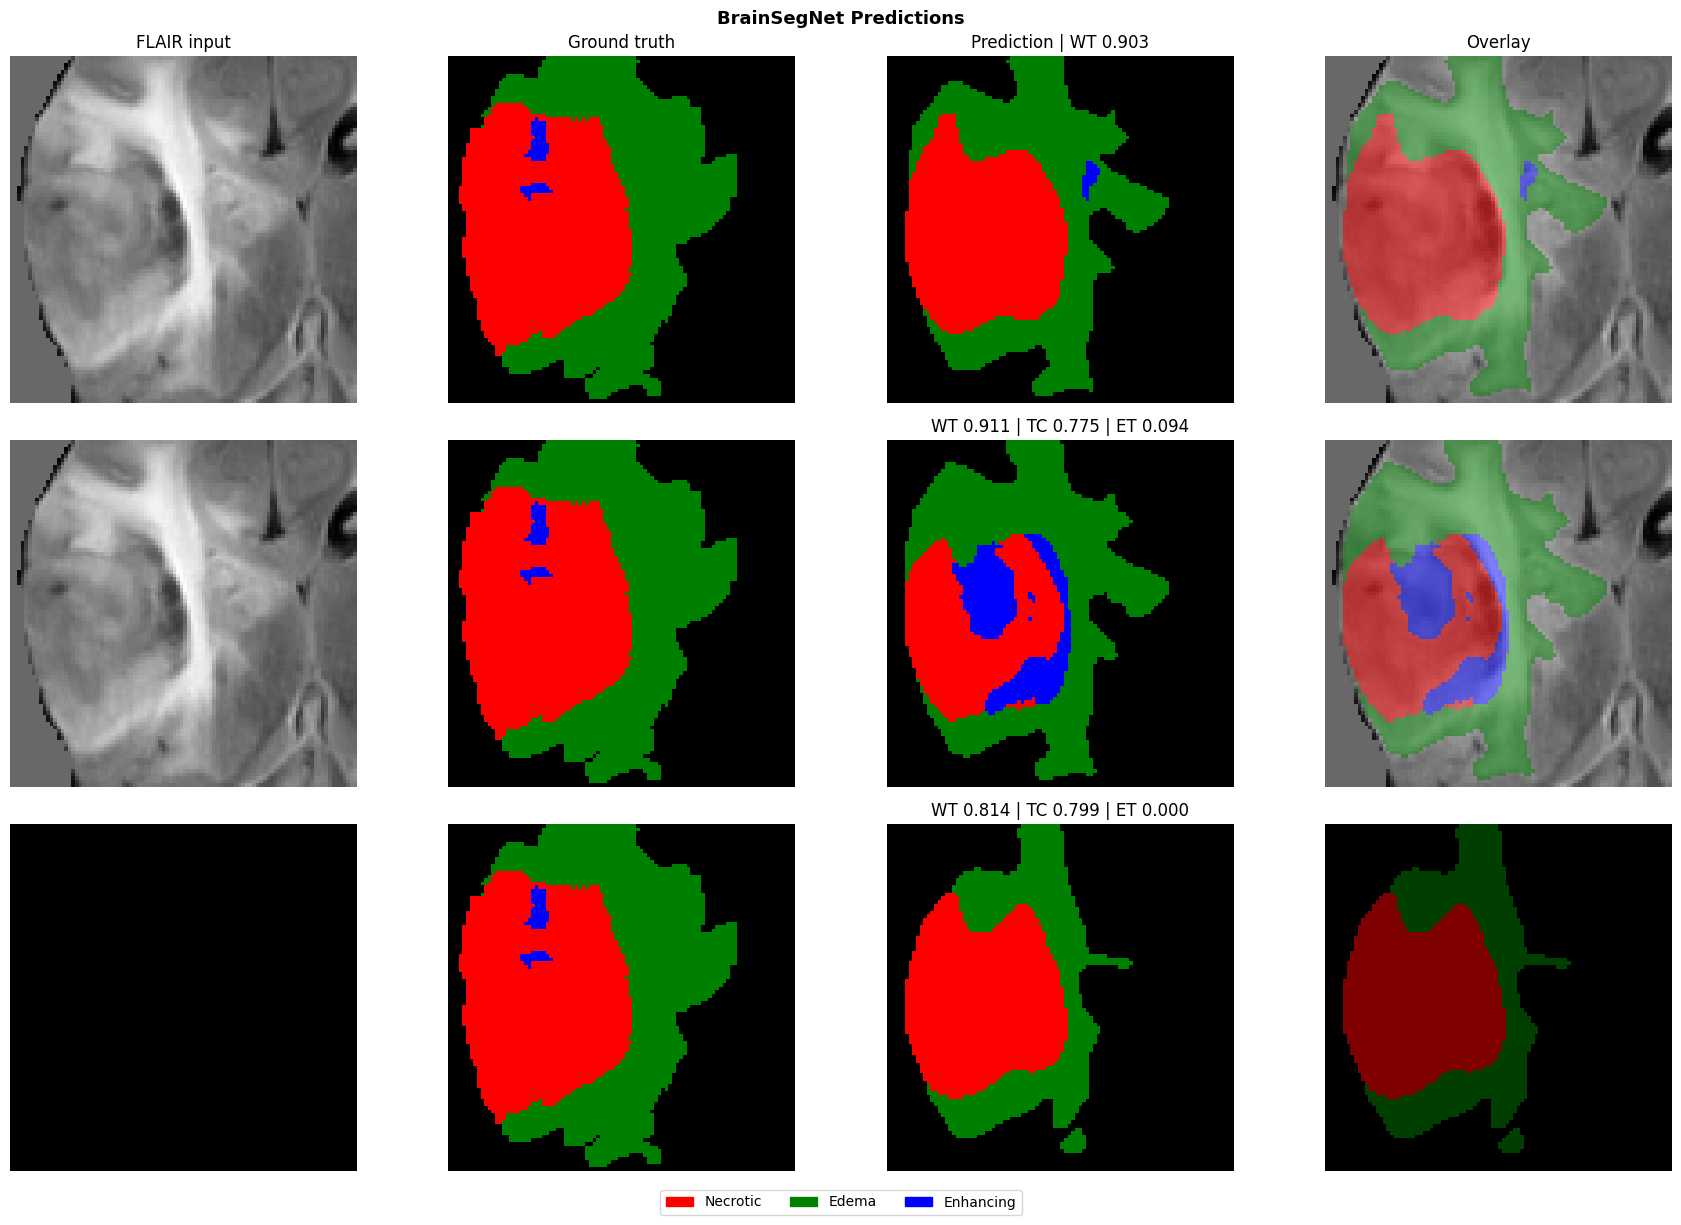

Saved -> /app/BrainSegNet/outputs/predictions.png


In [13]:
cmap_pred = mcolors.ListedColormap(['black','red','green','blue'])
eval_model.eval()

imgs_t, segs_t, _ = next(iter(te_loader))
imgs_t = imgs_t.to(DEVICE); segs_t = segs_t.to(DEVICE)

scenarios = [
    ('All 4 modalities', [1,1,1,1]),
    ('T1ce MISSING',     [1,0,1,1]),
    ('FLAIR MISSING',    [1,1,1,0]),
]

fig, axes = plt.subplots(len(scenarios), 4, figsize=(18, 4*len(scenarios)))
fig.suptitle('BrainSegNet Predictions', fontsize=13, fontweight='bold')

for row, (sname, mvals) in enumerate(scenarios):
    im2 = imgs_t.clone()
    for ch, pr in enumerate(mvals):
        if not pr: im2[:,ch] = 0.
    mk = torch.tensor([mvals], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        out  = eval_model(im2, mk, training=False)
        m    = dice_brats(out, segs_t)
        pred = out.argmax(1).cpu().numpy()[0]

    sn   = segs_t.cpu().numpy()[0]
    best = int((sn>0).sum(axis=(0,1)).argmax())
    fl   = im2[0,3].cpu().numpy()

    axes[row,0].imshow(fl[:,:,best].T,   cmap='gray',  origin='lower')
    axes[row,0].set_ylabel(sname, fontsize=9); axes[row,0].axis('off')
    if row==0: axes[row,0].set_title('FLAIR input')
    axes[row,1].imshow(sn[:,:,best].T,   cmap=cmap_pred, vmin=0,vmax=3, origin='lower')
    axes[row,1].axis('off')
    if row==0: axes[row,1].set_title('Ground truth')
    axes[row,2].imshow(pred[:,:,best].T, cmap=cmap_pred, vmin=0,vmax=3, origin='lower')
    axes[row,2].set_title(f'WT {m["WT"]:.3f} | TC {m["TC"]:.3f} | ET {m["ET"]:.3f}' if row else f'Prediction | WT {m["WT"]:.3f}')
    axes[row,2].axis('off')
    axes[row,3].imshow(fl[:,:,best].T, cmap='gray', origin='lower')                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     vvvv 
    import numpy.ma as ma
    ov = ma.masked_where(pred[:,:,best]==0, pred[:,:,best])
    axes[row,3].imshow(ov.T, cmap=cmap_pred, alpha=0.5, vmin=0,vmax=3, origin='lower')
    axes[row,3].axis('off')
    if row==0: axes[row,3].set_title('Overlay')

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='red',label='Necrotic'),
                     Patch(color='green',label='Edema'),
                     Patch(color='blue',label='Enhancing')],
           loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.03))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'predictions.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved -> {OUTPUT_DIR}/predictions.png")